# Proyecto Final — Generación de Música con LSTM

**Compositor:** Ludwig van Beethoven

---

## Índice
- [0.Imports y variables](#sec0): Librerías y parámetros globales
- [1.Lectura de datos](#sec1): Carga de archivos MIDI y construcción del DataFrame
- [2. EDA](#sec2): Análisis exploratorio de datos
    - [2.1 Número de canciones](#sec21): Conteo de canciones disponibles
    - [2.3 Vista rápida](#sec22): Primeras filas y estadísticas descriptivas
    - [2.4 Histogramas](#sec23): Distribuciones de notas y atributos
- [3. Procesamiento de datos](#sec3): Codificación de pitch y construcción del vocabulario
    - [3.1 Pitch](#sec31): Tabla de codificación MIDI y vocabularios de pitch class / octava

<a id="sec0"></a>
# 0. Imports y variables

In [64]:
# False → local  |  True → Google Colab
COLAB = True

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install pretty_midi


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
import os
import pretty_midi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [66]:
np.random.seed(42)

EDA    = False
artist = 'beeth'
Save = False

<a id="sec1"></a>
# 1. Lectura de datos

Carga los archivos MIDI del artista seleccionado y extrae las notas de cada instrumento de piano. Se construye un DataFrame unificado con todas las notas. Se añade la columna `song_id` (índice entero 0..n−1 por canción) y la columna `hand` (`hand_1`, `hand_2`, …) cuando una canción contiene más de un instrumento de piano.

In [67]:
if COLAB:
    DATA_PATH = f'/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/data/music_artist/{artist}'
else:
    DATA_PATH = f'./data/music_artist/{artist}'
TARGET_INS = 'Acoustic Grand Piano'

midi_files = sorted([os.path.join(DATA_PATH, f)
                     for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos MIDI encontrados: {len(midi_files)}')

def extract_notes(inst):
    rows, prev_start = [], None
    for note in sorted(inst.notes, key=lambda x: x.start):
        dur  = note.end - note.start
        step = note.start - prev_start if prev_start is not None else 0.0
        rows.append({
            'pitch':    note.pitch,
            'duration': dur,
            'step':     step,
            'velocity': note.velocity,
        })
        prev_start = note.start
    return rows

records = []
for sid, fpath in enumerate(midi_files):
    pm    = pretty_midi.PrettyMIDI(fpath)
    base  = os.path.basename(fpath)
    piano = [inst for inst in pm.instruments
             if pretty_midi.program_to_instrument_name(inst.program) == TARGET_INS
             and len(inst.notes) >= 10]
    for hi, inst in enumerate(piano):
        hand = f'hand_{hi+1}' if len(piano) > 1 else None
        for row in extract_notes(inst):
            row.update({'song_id': sid, 'song_name': base, 'hand': hand})
            records.append(row)

df = pd.DataFrame(records)[['song_id','song_name','hand','pitch','duration','step','velocity']]
print(f'Canciones con piano: {df["song_id"].nunique()}  |  Notas totales: {len(df):,}')

Archivos MIDI encontrados: 29
Canciones con piano: 23  |  Notas totales: 84,785


# 1.1 Train / Val / Test split

Se seleccionan **3 canciones aleatorias** para test. Del resto, el **10 %** (redondeado hacia arriba, mínimo 1) queda como validación. El split se hace a nivel de `song_name` para mantener ambas manos juntas. Los parámetros de normalización (bins, percentiles) se calculan **solo sobre train** para evitar data leakage.

In [68]:
all_songs  = df['song_name'].unique()
test_songs = np.random.choice(all_songs, size=3, replace=False)
remaining  = [s for s in all_songs if s not in test_songs]
n_val      = max(1, int(np.ceil(0.1 * len(remaining))))
val_songs  = np.random.choice(remaining, size=n_val, replace=False)
train_songs = [s for s in remaining if s not in val_songs]

df_test  = df[ df['song_name'].isin(test_songs)].reset_index(drop=True)
df_val   = df[ df['song_name'].isin(val_songs)].reset_index(drop=True)
df_train = df[ df['song_name'].isin(train_songs)].reset_index(drop=True)

print(f'Test  songs : {sorted(test_songs)}')
print(f'Val   songs : {sorted(val_songs)}')
print(f'Train songs : {len(train_songs)}  |  Val: {len(val_songs)}  |  Test: {len(test_songs)}')
print(f'Train notes : {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}')

Test  songs : ['appass_1.mid', 'beethoven_les_adieux_3.mid', 'beethoven_opus22_3.mid']
Val   songs : [np.str_('appass_3.mid'), np.str_('mond_1.mid')]
Train songs : 18  |  Val: 2  |  Test: 3
Train notes : 62,789  |  Val: 8,367  |  Test: 13,629


<a id="sec2"></a>
# 2. EDA

Análisis exploratorio del dataset. Todas las celdas de esta sección se ejecutan únicamente si `EDA = True`.

<a id="sec21"></a>
## 2.1 Número de canciones

Cuántos archivos MIDI hay disponibles y cuántas notas contiene cada canción.

In [69]:
if EDA:
    resumen = (df_train.groupby(['song_id', 'song_name'])['pitch']
                 .count()
                 .rename('n_notas')
                 .reset_index())
    print(f'Total de canciones de Beethoven (train): {len(resumen)}\n')
    display(resumen)

<a id="sec22"></a>
## 2.2 Vista rápida de los datos

Primeras filas del DataFrame general con todas las columnas, incluyendo `song_id` y `hand`, seguido de las estadísticas descriptivas.

In [70]:
if EDA:
    display(df_train.head(5))
    display(df_train.describe().round(3))

<a id="sec23"></a>
## 2.3 Histogramas por canción / atributo

Primero se muestra la cantidad de notas por canción. Luego, una gráfica individual por cada atributo continuo (`pitch`, `step`, `velocity`, `duration`), con la distribución de frecuencias, la media y la desviación estándar marcadas.

In [71]:
if EDA:
    # Notas por pista (cada mano/instrumento cuenta como archivo independiente)
    notas_por_pista = (df_train.groupby(['song_id', 'song_name', 'hand'])['pitch']
                         .count()
                         .rename('n_notas')
                         .reset_index())
    media = notas_por_pista['n_notas'].mean()
    std   = notas_por_pista['n_notas'].std()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(notas_por_pista['n_notas'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(media,       color='black', linewidth=2,   linestyle='-',  label=f'Media:  {media:.0f}')
    ax.axvline(media + std, color='black', linewidth=1.2, linestyle='--', label=f'+1 std: {media+std:.0f}')
    ax.axvline(media - std, color='black', linewidth=1.2, linestyle='--', label=f'−1 std: {media-std:.0f}')
    ax.set_title('Distribución de notas por archivo / pista (train)', fontsize=13)
    ax.set_xlabel('Notas totales')
    ax.set_ylabel('Número de archivos')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [72]:
if EDA:
    atributos = [
        ('pitch',    None, 'Pitch (MIDI 0–127)',  'steelblue',  40),
        ('step',     2.0,  'Step (s)',            'mediumseagreen', 50),
        ('velocity', None, 'Velocity (0–127)',    'darkorange', 40),
        ('duration', 2.0,  'Duración (s)',        'mediumpurple', 50),
    ]

    for col, clip, titulo, color, bins in atributos:
        datos = df_train[col].clip(0, clip).dropna() if clip else df_train[col].dropna()
        media, std = datos.mean(), datos.std()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(datos, bins=bins, color=color, edgecolor='white', alpha=0.85)

        ax.axvline(media,        color='black',  linewidth=2,   linestyle='-',  label=f'Media:  {media:.3f}')
        ax.axvline(media + std,  color='black',  linewidth=1.2, linestyle='--', label=f'+1 std: {media+std:.3f}')
        ax.axvline(media - std,  color='black',  linewidth=1.2, linestyle='--', label=f'−1 std: {media-std:.3f}')

        ax.set_title(f'Distribución — {titulo} (train)', fontsize=13)
        ax.set_xlabel(titulo)
        ax.set_ylabel('Frecuencia')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

<a id="sec3"></a>
# 3. Procesamiento de datos

<a id="sec31"></a>
## 3.1 Pitch

Se construyen las estructuras de codificación necesarias para representar las notas MIDI como tokens discretos. El pitch MIDI (0–127) se descompone en **pitch class** (nota dentro de la octava, 0–11) y **octava** (−1 a 9), reduciendo el vocabulario y añadiendo estructura musical al modelo.

Tabla de referencia que mapea cada valor MIDI a su nombre de nota, pitch class y octava.

In [73]:
pitch_table = pd.DataFrame({
    'pitch':       range(128),
    'note_name':   [pretty_midi.note_number_to_name(p) for p in range(128)],
    'pitch_class': [p % 12        for p in range(128)],
    'octave':      [(p // 12) - 1 for p in range(128)],
    'octave_idx':  [p // 12       for p in range(128)],
})

PITCH_CLASS_VOCAB = 12
OCTAVE_VOCAB      = 11

print('Muestra de la tabla de codificación MIDI:')
display(pitch_table.iloc[[0, 12, 24, 36, 48, 60, 69, 72, 84, 96, 108, 127]])
print(f'\npitch_class vocab: {PITCH_CLASS_VOCAB}  |  octave vocab: {OCTAVE_VOCAB}')

Muestra de la tabla de codificación MIDI:


,pitch,note_name,pitch_class,octave,octave_idx
0,0,C-1,0,-1,0
12,12,C0,0,0,1
24,24,C1,0,1,2
36,36,C2,0,2,3
48,48,C3,0,3,4
60,60,C4,0,4,5
69,69,A4,9,4,5
72,72,C5,0,5,6
84,84,C6,0,6,7
96,96,C7,0,7,8



pitch_class vocab: 12  |  octave vocab: 11


<a id="sec32"></a>
## 3.2 Normalización — step y duration

In [74]:
N_BINS = 8  # bins equiprobables para step y duration


### 3.2.1 step

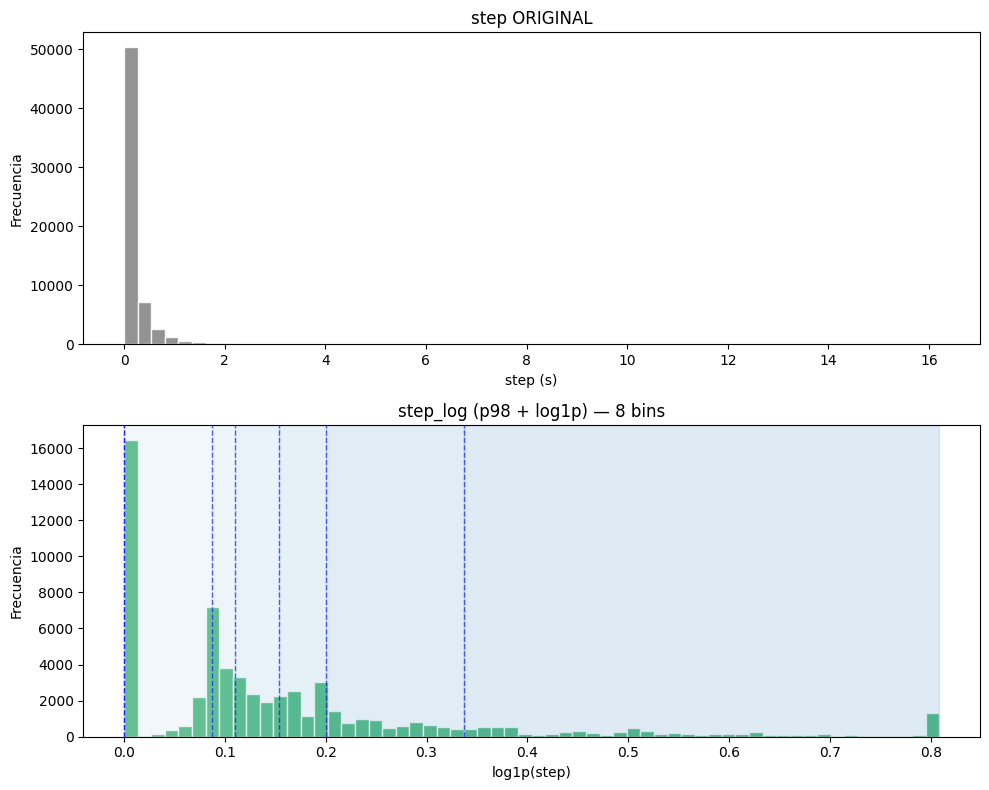

p98=1.245 | edges=[0.    0.    0.    0.087 0.11  0.154 0.201 0.337 0.808]


In [75]:
p98 = df_train["step"].quantile(0.98)

step = df_train["step"]
step_log = np.log1p(step.clip(0, p98))
edges = np.quantile(step_log, np.linspace(0, 1, N_BINS + 1))

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# ORIGINAL
ax[0].hist(step, bins=60, color="gray", edgecolor="white", alpha=0.85)
ax[0].set(title="step ORIGINAL", xlabel="step (s)", ylabel="Frecuencia")

# TRANSFORMADO
ax[1].hist(step_log, bins=60, color="mediumseagreen", edgecolor="white", alpha=0.85)

for i, (l, r) in enumerate(zip(edges[:-1], edges[1:])):
    ax[1].axvspan(l, r, color=plt.cm.Blues(0.2 + 0.6*i/N_BINS), alpha=0.15)

for e in edges[1:-1]:
    ax[1].axvline(e, ls="--", lw=1, color="blue", alpha=0.6)

ax[1].set(title=f"step_log (p98 + log1p) — {N_BINS} bins", xlabel="log1p(step)", ylabel="Frecuencia")

plt.tight_layout()
plt.show()

print(f"p98={p98:.3f} | edges={edges.round(3)}")

### 3.2.2 duration

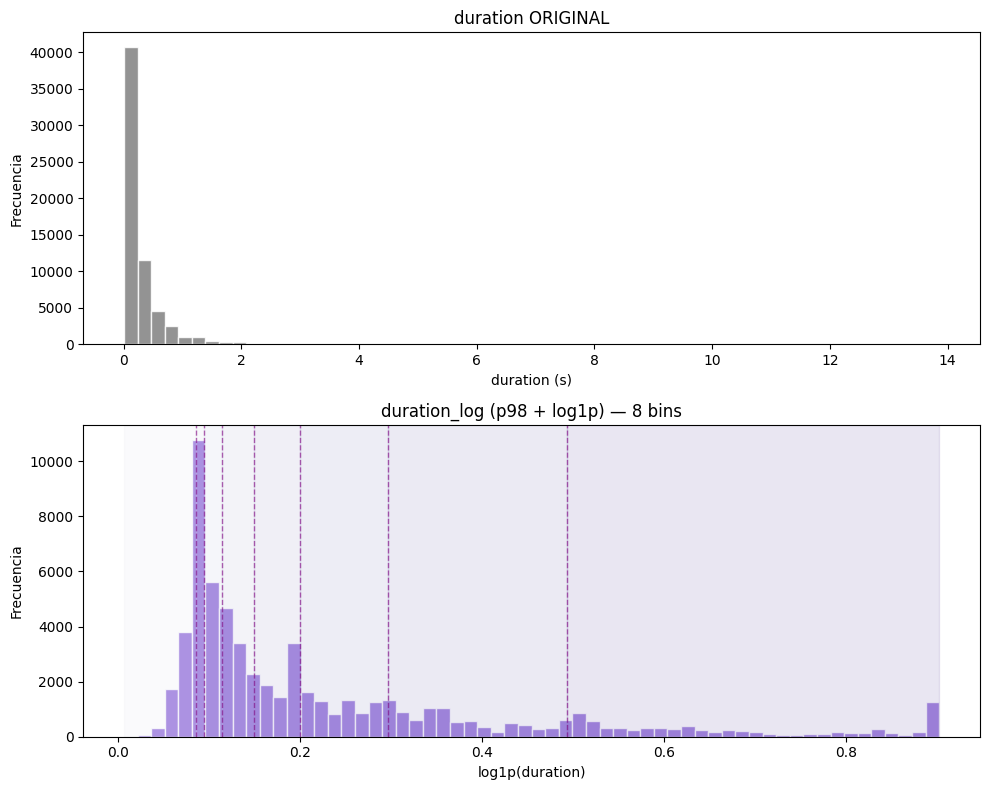

p98=1.466 | edges=[0.007 0.086 0.094 0.115 0.15  0.201 0.297 0.494 0.903]


In [76]:
p98 = df_train["duration"].quantile(0.98)

dur = df_train["duration"]
dur_log = np.log1p(dur.clip(0, p98))
edges = np.quantile(dur_log, np.linspace(0, 1, N_BINS + 1))

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# ORIGINAL
ax[0].hist(dur, bins=60, color="gray", edgecolor="white", alpha=0.85)
ax[0].set(title="duration ORIGINAL", xlabel="duration (s)", ylabel="Frecuencia")

# TRANSFORMADO
ax[1].hist(dur_log, bins=60, color="mediumpurple", edgecolor="white", alpha=0.85)

for i, (l, r) in enumerate(zip(edges[:-1], edges[1:])):
    ax[1].axvspan(l, r, color=plt.cm.Purples(0.2 + 0.6*i/N_BINS), alpha=0.15)

for e in edges[1:-1]:
    ax[1].axvline(e, ls="--", lw=1, color="purple", alpha=0.6)

ax[1].set(title=f"duration_log (p98 + log1p) — {N_BINS} bins", xlabel="log1p(duration)", ylabel="Frecuencia")

plt.tight_layout()
plt.show()

print(f"p98={p98:.3f} | edges={edges.round(3)}")

<a id="sec33"></a>
## 3.2 Transformación completa

In [77]:
def transform_df(df, n_bins=8, p=0.98):
    x = df.copy()

    # Pitch
    pitch_class = (x["pitch"] % 12).astype(int)
    octave = (x["pitch"] // 12).astype(int)

    # Step
    p_step_val = x["step"].quantile(p)
    step_log = np.log1p(x["step"].clip(0, p_step_val))
    step_edges = np.quantile(step_log, np.linspace(0, 1, n_bins + 1))
    step_bin = np.digitize(step_log, step_edges[1:-1]).astype(int)

    # Duration
    p_dur_val = x["duration"].quantile(p)
    dur_log = np.log1p(x["duration"].clip(0, p_dur_val))
    dur_edges = np.quantile(dur_log, np.linspace(0, 1, n_bins + 1))
    dur_bin = np.digitize(dur_log, dur_edges[1:-1]).astype(int)

    # Velocity
    velocity_norm = (x["velocity"] / 127.0).round(4)


    out = pd.DataFrame({
        "song_id": x["song_id"].values,
        "song_name": x["song_name"].values,
        "hand": x["hand"].values,
        "pitch_class": pitch_class.values,
        "octave": octave.values,
        "step_bin": step_bin,
        "dur_bin": dur_bin,
        "velocity_norm": velocity_norm.values,
    })

    params = {
        "p_step": p_step_val,
        "p_dur": p_dur_val,
        "step_edges": step_edges,
        "dur_edges": dur_edges,
        "n_bins": n_bins,
    }
    return out, params


def df_to_sequences(df):
    sequences = []

    for _, group in df.groupby(["song_id", "hand"]):
        seq = group[[
            "pitch_class",
            "octave",
            "step_bin",
            "dur_bin",
            "velocity_norm"
        ]].values.tolist()
        sequences.append(seq)

    return sequences

In [78]:
df_train_t, params = transform_df(df_train, n_bins=8)
df_train_t

,song_id,song_name,hand,pitch_class,octave,step_bin,dur_bin,velocity_norm
0,1,appass_2.mid,hand_1,8,4,2,7,0.3701
1,1,appass_2.mid,hand_1,5,4,2,7,0.3071
2,1,appass_2.mid,hand_1,1,4,2,7,0.3071
3,1,appass_2.mid,hand_1,6,4,7,7,0.3465
4,1,appass_2.mid,hand_1,10,4,2,7,0.3465
...,...,...,...,...,...,...,...,...
62784,22,mond_3.mid,hand_2,8,3,2,5,0.6220
62785,22,mond_3.mid,hand_2,1,4,7,5,0.6220
62786,22,mond_3.mid,hand_2,8,3,2,5,0.6220
62787,22,mond_3.mid,hand_2,1,3,2,5,0.5276


In [79]:
train_sequences = df_to_sequences(df_train_t)
print(f"Número de secuencias: {len(train_sequences)}")
print(f"Numero de notas en la primer secuencia: {len(train_sequences[0])}")
print(f"Ejemplo de una nota: {train_sequences[0][0]}")

Número de secuencias: 36
Numero de notas en la primer secuencia: 1128
Ejemplo de una nota: [8.0, 4.0, 2.0, 7.0, 0.3701]


<a id="sec4"></a>
# 4. DataLoader

Val split (2 canciones del train), transformación del test con parámetros del train, y ventanas deslizantes de `BLOCK_SIZE` notas.

- **Entrada por nota:** `[pitch_class, octave, step_bin, dur_bin, velocity_norm]` → 5 features  
- **`x`:** ventana de `BLOCK_SIZE` notas consecutivas | **`y`:** nota siguiente (target)

In [80]:
import torch

BLOCK_SIZE = 100
BATCH_SIZE = 64

# Transformar val y test con los parámetros del train (sin data leakage)
def apply_params(df, p):
    x     = df.copy()
    s_log = np.log1p(x['step'].clip(0, p['p_step']))
    d_log = np.log1p(x['duration'].clip(0, p['p_dur']))
    return pd.DataFrame({
        'song_id':       x['song_id'].values,
        'song_name':     x['song_name'].values,
        'hand':          x['hand'].values,
        'pitch_class':   (x['pitch'] % 12).astype(int).values,
        'octave':        (x['pitch'] // 12).astype(int).values,
        'step_bin':      np.digitize(s_log, p['step_edges'][1:-1]).astype(int),
        'dur_bin':       np.digitize(d_log, p['dur_edges'][1:-1]).astype(int),
        'velocity_norm': (x['velocity'] / 127.0).values,
    })

df_val_t  = apply_params(df_val,  params)
df_test_t = apply_params(df_test, params)

train_seqs = df_to_sequences(df_train_t)
val_seqs   = df_to_sequences(df_val_t)
test_seqs  = df_to_sequences(df_test_t)

print(f'Secuencias — train: {len(train_seqs)}  val: {len(val_seqs)}  test: {len(test_seqs)}')

Secuencias — train: 36  val: 5  test: 6


In [81]:
class MusicDataLoader:
    def __init__(self, seqs, block_size):
        self.block_size = block_size
        self.seqs = [torch.tensor(s, dtype=torch.float32) for s in seqs]
        self.idx  = [(si, st) for si, s in enumerate(self.seqs)
                     for st in range(len(s) - block_size)]
        self._shuffle()

    def _shuffle(self):
        self.order, self.pos = np.random.permutation(len(self.idx)), 0

    def get_batch(self, batch_size):
        batch = self.order[self.pos : self.pos + batch_size]
        self.pos += len(batch)
        if len(batch) < batch_size:
            self._shuffle()
            if not len(batch):
                batch, self.pos = self.order[:batch_size], batch_size
        xs, ys = [], []
        for i in batch:
            si, st = self.idx[i]
            xs.append(self.seqs[si][st : st + self.block_size])
            ys.append(self.seqs[si][st + self.block_size])
        return torch.stack(xs), torch.stack(ys)

    @property
    def n_examples(self): return len(self.idx)


train_loader = MusicDataLoader(train_seqs, BLOCK_SIZE)
val_loader   = MusicDataLoader(val_seqs,   BLOCK_SIZE)
test_loader  = MusicDataLoader(test_seqs,  BLOCK_SIZE)

xb, yb = train_loader.get_batch(BATCH_SIZE)
print(f'Ventanas — train: {train_loader.n_examples:,}  val: {val_loader.n_examples:,}  test: {test_loader.n_examples:,}')
print(f'x: {tuple(xb.shape)}  →  (batch, contexto, features)')
print(f'y: {tuple(yb.shape)}  →  nota objetivo')

Ventanas — train: 59,189  val: 7,867  test: 13,029
x: (64, 100, 5)  →  (batch, contexto, features)
y: (64, 5)  →  nota objetivo


<a id="sec5"></a>
# 5. Modelo LSTM

<a id="sec51"></a>
## 5.1 Definición de arquitectura

Se define una LSTM apilada con **3 capas**, dimensión oculta de **256** y dropout de **0.3**.

Las cuatro features discretas se representan mediante **embeddings aprendibles**:

| Feature | Vocab | Emb dim |
|---|---|---|
| `pitch_class` | 12 | 8 |
| `octave` | 11 | 4 |
| `step_bin` | 8 | 4 |
| `dur_bin` | 8 | 4 |

La `velocity` se trata como variable continua y se concatena directamente (sin embedding).  
El vector de entrada a la LSTM por paso de tiempo tiene dimensión `8+4+4+4+1 = 21`.

Cada cabeza de salida predice una feature de la **siguiente nota**.

In [82]:
# ── Hiperparámetros — Sección 5 ───────────────────────────────────────
LSTM_LAYERS = 3
HIDDEN_DIM  = 256
DROPOUT     = 0.3

EMB_PITCH   = 8    # pitch_class  (vocab = PITCH_CLASS_VOCAB = 12)
EMB_OCTAVE  = 4    # octave       (vocab = OCTAVE_VOCAB      = 11)
EMB_STEP    = 4    # step_bin     (vocab = N_BINS            =  8)
EMB_DUR     = 4    # dur_bin      (vocab = N_BINS            =  8)

INPUT_DIM   = EMB_PITCH + EMB_OCTAVE + EMB_STEP + EMB_DUR + 1  # +1 velocity continua

print(f'LSTM capas: {LSTM_LAYERS}  |  hidden: {HIDDEN_DIM}  |  dropout: {DROPOUT}')
print(f'Dims embedding — pitch: {EMB_PITCH}  octave: {EMB_OCTAVE}  step: {EMB_STEP}  dur: {EMB_DUR}')
print(f'Dimensión de entrada a la LSTM: {INPUT_DIM}')

LSTM capas: 3  |  hidden: 256  |  dropout: 0.3
Dims embedding — pitch: 8  octave: 4  step: 4  dur: 4
Dimensión de entrada a la LSTM: 21


In [83]:
class MusicLSTM(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # Embeddings aprendibles para features discretas
        self.emb_pitch  = torch.nn.Embedding(PITCH_CLASS_VOCAB, EMB_PITCH)
        self.emb_octave = torch.nn.Embedding(OCTAVE_VOCAB,      EMB_OCTAVE)
        self.emb_step   = torch.nn.Embedding(N_BINS,            EMB_STEP)
        self.emb_dur    = torch.nn.Embedding(N_BINS,            EMB_DUR)

        self.lstm = torch.nn.LSTM(
            input_size=INPUT_DIM,
            hidden_size=HIDDEN_DIM,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            dropout=DROPOUT,
        )

        # Cabezas de predicción (una por feature de la nota objetivo)
        self.head_pitch  = torch.nn.Linear(HIDDEN_DIM, PITCH_CLASS_VOCAB)  # logits 12 clases
        self.head_octave = torch.nn.Linear(HIDDEN_DIM, OCTAVE_VOCAB)       # logits 11 clases
        self.head_step   = torch.nn.Linear(HIDDEN_DIM, N_BINS)             # logits  8 clases
        self.head_dur    = torch.nn.Linear(HIDDEN_DIM, N_BINS)             # logits  8 clases
        self.head_vel    = torch.nn.Linear(HIDDEN_DIM, 1)                  # regresión continua

    def forward(self, x):
        # x: (batch, seq_len, 5)  →  [pitch_class, octave, step_bin, dur_bin, velocity_norm]
        pc  = x[:, :, 0].long()          # (batch, seq_len)
        oct_ = x[:, :, 1].long()
        st  = x[:, :, 2].long()
        dur = x[:, :, 3].long()
        vel = x[:, :, 4].unsqueeze(-1)   # (batch, seq_len, 1)  — continua

        emb = torch.cat([
            self.emb_pitch(pc),           # (batch, seq_len, EMB_PITCH)
            self.emb_octave(oct_),        # (batch, seq_len, EMB_OCTAVE)
            self.emb_step(st),            # (batch, seq_len, EMB_STEP)
            self.emb_dur(dur),            # (batch, seq_len, EMB_DUR)
            vel,                          # (batch, seq_len, 1)
        ], dim=-1)                        # (batch, seq_len, INPUT_DIM)

        out, _ = self.lstm(emb)           # (batch, seq_len, HIDDEN_DIM)
        h = out[:, -1, :]                 # último paso → (batch, HIDDEN_DIM)

        return {
            'pitch':  self.head_pitch(h),              # (batch, 12)
            'octave': self.head_octave(h),             # (batch, 11)
            'step':   self.head_step(h),               # (batch,  8)
            'dur':    self.head_dur(h),                # (batch,  8)
            'vel':    self.head_vel(h).squeeze(-1),    # (batch,)
        }


model = MusicLSTM()
n_params = sum(p.nelement() for p in model.parameters())
print(f'El modelo tiene {n_params:,} parámetros.')
print()
print(model)

El modelo tiene 1,348,852 parámetros.

MusicLSTM(
  (emb_pitch): Embedding(12, 8)
  (emb_octave): Embedding(11, 4)
  (emb_step): Embedding(8, 4)
  (emb_dur): Embedding(8, 4)
  (lstm): LSTM(21, 256, num_layers=3, batch_first=True, dropout=0.3)
  (head_pitch): Linear(in_features=256, out_features=12, bias=True)
  (head_octave): Linear(in_features=256, out_features=11, bias=True)
  (head_step): Linear(in_features=256, out_features=8, bias=True)
  (head_dur): Linear(in_features=256, out_features=8, bias=True)
  (head_vel): Linear(in_features=256, out_features=1, bias=True)
)


In [84]:
def draw_architecture(model):
    """
    Dibuja el diagrama de arquitectura del modelo inspeccionando sus capas dinámicamente.
    Detecta automáticamente:
      - nn.Embedding  → capa de embedding por feature discreta
      - nn.LSTM       → capas recurrentes apiladas
      - nn.Linear     → cabezas de salida (Linear con out=1 → MSE, out>1 → CrossEntropy)
    """
    import torch.nn as nn
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    # ── 1. Introspección ─────────────────────────────────────────────────────
    embeddings = {}   # name → {vocab, dim}
    lstm_info  = {}
    heads      = {}   # name → {in_features, out_features}

    for name, module in model.named_children():
        if isinstance(module, nn.Embedding):
            embeddings[name] = {'vocab': module.num_embeddings, 'dim': module.embedding_dim}
        elif isinstance(module, nn.LSTM):
            lstm_info = {
                'input_size':  module.input_size,
                'hidden_size': module.hidden_size,
                'num_layers':  module.num_layers,
                'dropout':     round(float(module.dropout), 2),
            }
        elif isinstance(module, nn.Linear):
            heads[name] = {'in': module.in_features, 'out': module.out_features}

    if not lstm_info:
        raise ValueError("No se encontró una capa nn.LSTM en el modelo.")

    emb_dim_sum  = sum(v['dim'] for v in embeddings.values())
    n_continuous = lstm_info['input_size'] - emb_dim_sum   # features continuas (ej. velocity)
    n_layers     = lstm_info['num_layers']
    hidden_dim   = lstm_info['hidden_size']
    dropout      = lstm_info['dropout']

    # Construir lista de features (embeddings primero, luego continuas)
    feat_list = [(name, f"{name.replace('emb_','')}\n(vocab {info['vocab']})", 'emb', info)
                 for name, info in embeddings.items()]
    if n_continuous == 1:
        feat_list.append(('velocity', 'velocity\n(continua)', 'cont', None))
    elif n_continuous > 1:
        feat_list.append(('continuous', f'continuas\n(×{n_continuous})', 'cont', None))

    n_feats = len(feat_list)
    n_heads = len(heads)

    # ── 2. Layout ────────────────────────────────────────────────────────────
    FIG_W = max(14, max(n_feats, n_heads) * 2.8)
    lstm_block_h = n_layers * 0.90 - 0.15   # altura total de todas las capas LSTM

    # Posiciones Y (de abajo hacia arriba)
    Y_FEAT   = 0.40
    Y_EMB    = 1.90
    Y_CAT    = 3.15
    Y_LSTM   = 3.65
    Y_HEAD   = Y_LSTM + lstm_block_h + 1.00
    Y_LOSS   = Y_HEAD + 1.15
    FIG_H    = Y_LOSS + 1.10

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    ax.set_xlim(0, FIG_W)
    ax.set_ylim(0, FIG_H)
    ax.axis('off')
    ax.set_title(f'Arquitectura: {type(model).__name__}', fontsize=15,
                 fontweight='bold', pad=16)

    # Paleta
    C_IN   = '#E3F2FD'
    C_CONT = '#F3E5F5'
    C_EMB  = '#FFF3E0'
    C_LSTM = '#E8F5E9'
    C_HEAD = '#FFEBEE'
    C_CE   = '#FFCDD2'
    C_MSE  = '#C8E6C9'
    BORDER = '#37474F'

    # ── Helpers ──────────────────────────────────────────────────────────────
    def rect(xc, yb, w, h, fc, ec=BORDER, lw=1.5, **kw):
        p = mpatches.FancyBboxPatch((xc - w/2, yb), w, h,
                                    boxstyle='round,pad=0.08',
                                    facecolor=fc, edgecolor=ec, lw=lw, **kw)
        ax.add_patch(p)

    def arrow(x0, y0, x1, y1, color=BORDER, lw=1.3, style='->', ls='-'):
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle=style, color=color, lw=lw,
                                   linestyle=ls, connectionstyle='arc3,rad=0.0'))

    margin  = 1.2
    feat_cw = (FIG_W - 2 * margin) / n_feats
    head_cw = (FIG_W - 2 * margin) / n_heads
    feat_xs = [margin + (i + 0.5) * feat_cw for i in range(n_feats)]
    head_xs = [margin + (j + 0.5) * head_cw for j in range(n_heads)]
    feat_bw = min(feat_cw * 0.82, 2.4)
    head_bw = min(head_cw * 0.82, 2.6)

    # ── Nivel 1: Input features ───────────────────────────────────────────
    for i, (name, label, ftype, _) in enumerate(feat_list):
        fc = C_CONT if ftype == 'cont' else C_IN
        rect(feat_xs[i], Y_FEAT, feat_bw, 0.90, fc)
        ax.text(feat_xs[i], Y_FEAT + 0.45, label,
                fontsize=8, ha='center', va='center')

    # ── Nivel 2: Embedding boxes / passthrough ───────────────────────────
    for i, (name, label, ftype, info) in enumerate(feat_list):
        xc = feat_xs[i]
        if ftype == 'emb':
            arrow(xc, Y_FEAT + 0.90, xc, Y_EMB, lw=1.0, color='gray')
            rect(xc, Y_EMB, feat_bw, 0.80, C_EMB)
            ax.text(xc, Y_EMB + 0.40,
                    f'Emb({info["vocab"]}→{info["dim"]}d)',
                    fontsize=8, ha='center', va='center')
            arrow(xc, Y_EMB + 0.80, xc, Y_CAT + 0.22, lw=1.0, color='gray')
        else:
            # Continua: flecha punteada directa
            arrow(xc, Y_FEAT + 0.90, xc, Y_CAT + 0.22, lw=1.0, color='gray', ls='dashed')
            ax.text(xc, Y_EMB + 0.40, 'passthrough',
                    fontsize=7, ha='center', va='center', color='gray', style='italic')

    # ── Concatenación ─────────────────────────────────────────────────────
    input_dim = lstm_info['input_size']
    ax.text(FIG_W / 2, Y_CAT,
            f'Concat  →  vector dim = {input_dim}',
            fontsize=9, ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.30', facecolor='#F5F5F5', edgecolor=BORDER))
    # Línha horizontal conectando las flechas
    x_lo = feat_xs[0]
    x_hi = feat_xs[-1]
    ax.plot([x_lo, x_hi], [Y_CAT + 0.22, Y_CAT + 0.22], color='gray', lw=0.8, ls=':')
    arrow(FIG_W / 2, Y_CAT - 0.28, FIG_W / 2, Y_LSTM, lw=1.5)

    # ── LSTM layers ───────────────────────────────────────────────────────
    lstm_bw = FIG_W * 0.58
    layer_h = 0.72
    gap     = 0.18
    for k in range(n_layers):
        yb      = Y_LSTM + k * (layer_h + gap)
        in_s    = input_dim if k == 0 else hidden_dim
        drop_tx = f'  →  Dropout({dropout})' if k < n_layers - 1 and dropout > 0 else ''
        rect(FIG_W / 2, yb, lstm_bw, layer_h, C_LSTM)
        ax.text(FIG_W / 2, yb + layer_h / 2,
                f'LSTM capa {k+1}:  input={in_s}  →  hidden={hidden_dim}{drop_tx}',
                fontsize=9, ha='center', va='center')
        if k < n_layers - 1:
            arrow(FIG_W / 2, yb + layer_h, FIG_W / 2, yb + layer_h + gap, lw=1.2)

    y_lstm_top = Y_LSTM + n_layers * (layer_h + gap) - gap
    ax.text(FIG_W / 2 + 0.3, y_lstm_top + 0.45,
            f'h_t  (dim={hidden_dim})', fontsize=8, va='center', color='gray')
    arrow(FIG_W / 2, y_lstm_top, FIG_W / 2, Y_HEAD, lw=1.5)

    # ── Output heads ──────────────────────────────────────────────────────
    for j, (hname, hinfo) in enumerate(heads.items()):
        xc     = head_xs[j]
        is_reg = (hinfo['out'] == 1)
        short  = hname.replace('head_', '')
        loss_lbl = 'MSE'       if is_reg else 'CrossEntropy'
        loss_fc  = C_MSE       if is_reg else C_CE
        loss_ec  = 'darkgreen' if is_reg else 'red'

        # Fan-out desde el centro del LSTM al head
        arrow(FIG_W / 2, Y_HEAD - 0.05, xc, Y_HEAD, lw=1.0, color='gray')

        rect(xc, Y_HEAD, head_bw, 1.00, C_HEAD)
        ax.text(xc, Y_HEAD + 0.50,
                f'{short}\nLinear({hinfo["in"]}→{hinfo["out"]})',
                fontsize=8, ha='center', va='center', fontweight='bold')

        arrow(xc, Y_HEAD + 1.00, xc, Y_LOSS - 0.22, lw=0.9, color='gray')
        ax.text(xc, Y_LOSS,
                loss_lbl, fontsize=8, ha='center', va='center',
                fontweight='bold', color=loss_ec,
                bbox=dict(boxstyle='round,pad=0.25', facecolor=loss_fc, edgecolor=loss_ec, alpha=0.85))

    plt.tight_layout()

    if Save:
        out = 'arquitectura_modelo.png'
        plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
        print(f'Diagrama guardado como: {out}')
    plt.show()


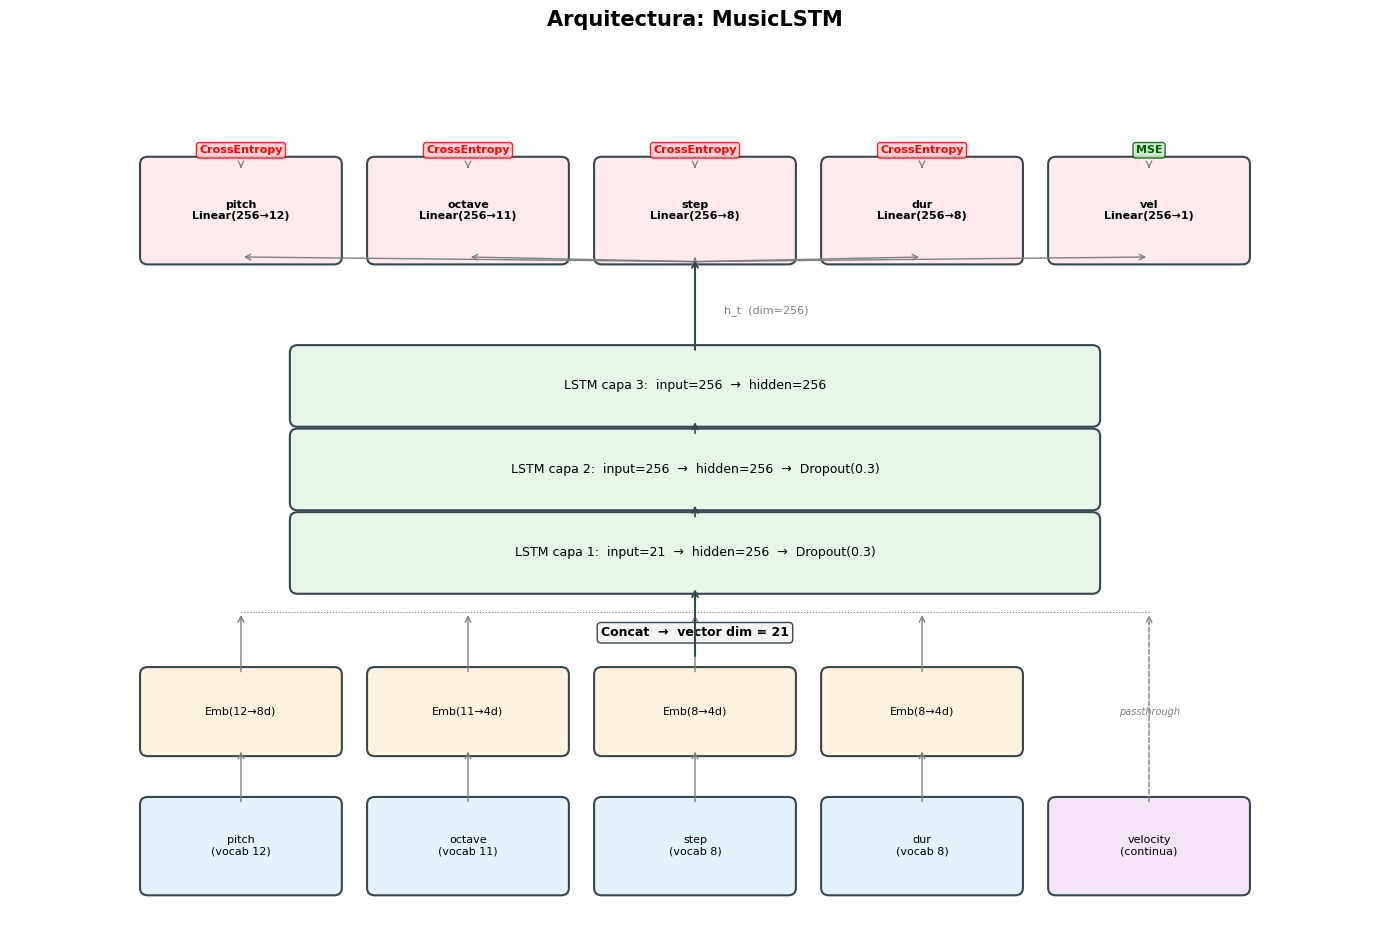

In [85]:
draw_architecture(model)

<a id="sec52"></a>
## 5.2 Entrenamiento

Bucle de entrenamiento con Adam y pérdida compuesta (cross-entropy por feature discreta + MAE para velocity). Se evalúa cada `EVAL_EVERY` pasos sobre `EVAL_BATCHES` batches de train y val.

In [86]:
import torch.nn as nn

ce_loss  = nn.CrossEntropyLoss()
ce_loss = nn.CrossEntropyLoss(label_smoothing=0.05)
mae_loss = nn.L1Loss()

W_PC, W_OCT, W_STEP, W_DUR, W_VEL = 2.0, 1.0, 1.0, 1.0, 1.0
LOSS_KEYS = ['total', 'pc', 'oct', 'step', 'dur', 'vel']

def composed_loss(out, y):
    """out: dict con 'pitch','octave','step','dur','vel'  |  y: (B,5)"""
    y_pc, y_oct, y_step, y_dur, y_vel = (
        y[:,0].long(), y[:,1].long(), y[:,2].long(), y[:,3].long(), y[:,4].float()
    )
    l_pc   = ce_loss(out['pitch'],  y_pc)
    l_oct  = ce_loss(out['octave'], y_oct)
    l_step = ce_loss(out['step'],   y_step)
    l_dur  = ce_loss(out['dur'],    y_dur)
    l_vel  = mae_loss(out['vel'],   y_vel)
    total  = W_PC*l_pc + W_OCT*l_oct + W_STEP*l_step + W_DUR*l_dur + W_VEL*l_vel
    return total, l_pc, l_oct, l_step, l_dur, l_vel


In [87]:
LR          = 1e-3
MAX_STEPS   = 5000
EVAL_EVERY  = 100
EVAL_BATCHES = 20

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

@torch.no_grad()
def estimate_loss(model, loader, n=EVAL_BATCHES):
    model.eval()
    acc = torch.zeros(len(LOSS_KEYS))
    for _ in range(n):
        x, y = loader.get_batch(BATCH_SIZE)
        losses = composed_loss(model(x.to(device)), y.to(device))
        acc += torch.tensor([l.item() for l in losses])
    model.train()
    return (acc / n).tolist()

def training_loop(model, train_loader, val_loader,
                  lr=LR, max_steps=MAX_STEPS, weight_decay=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history   = {k: [] for k in ['train_' + k for k in LOSS_KEYS] + ['val_' + k for k in LOSS_KEYS]}

    model.train()
    print(f'Entrenando por {max_steps} pasos en {device}')
    for step in range(max_steps):
        x, y = train_loader.get_batch(BATCH_SIZE)
        total, *_ = composed_loss(model(x.to(device)), y.to(device))
        optimizer.zero_grad(); total.backward(); optimizer.step()

        if (step + 1) % EVAL_EVERY == 0 or step == 0 or step == max_steps - 1:
            tr = estimate_loss(model, train_loader)
            vl = estimate_loss(model, val_loader)
            for k, tv, vv in zip(LOSS_KEYS, tr, vl):
                history['train_' + k].append(tv)
                history['val_'   + k].append(vv)
            print(f'Step {step+1:4d} | '
                  f'train {tr[0]:.3f} | val {vl[0]:.3f} | '
                  f'pc {tr[1]:.2f}/{vl[1]:.2f}  '
                  f'oct {tr[2]:.2f}/{vl[2]:.2f}  '
                  f'step {tr[3]:.2f}/{vl[3]:.2f}  '
                  f'dur {tr[4]:.2f}/{vl[4]:.2f}  '
                  f'vel {tr[5]:.3f}/{vl[5]:.3f}')
    return history

history = training_loop(model, train_loader, val_loader)


Entrenando por 5000 pasos en cuda
Step    1 | train 11.830 | val 11.859 | pc 2.48/2.48  oct 2.37/2.37  step 2.08/2.07  dur 2.08/2.09  vel 0.330/0.378
Step  100 | train 8.955 | val 8.807 | pc 2.44/2.46  oct 1.26/1.42  step 1.20/1.07  dur 1.51/1.30  vel 0.101/0.097
Step  200 | train 8.393 | val 8.235 | pc 2.34/2.48  oct 1.15/1.18  step 1.17/1.11  dur 1.31/0.89  vel 0.091/0.092
Step  300 | train 8.012 | val 8.001 | pc 2.28/2.41  oct 1.11/1.13  step 1.07/1.05  dur 1.17/0.91  vel 0.091/0.090
Step  400 | train 7.798 | val 7.669 | pc 2.21/2.33  oct 1.12/1.09  step 1.03/1.07  dur 1.14/0.78  vel 0.090/0.082
Step  500 | train 7.688 | val 7.694 | pc 2.22/2.36  oct 1.06/1.09  step 1.00/1.04  dur 1.09/0.75  vel 0.088/0.094
Step  600 | train 7.743 | val 7.605 | pc 2.26/2.32  oct 1.08/1.09  step 0.99/1.01  dur 1.08/0.77  vel 0.089/0.095
Step  700 | train 7.600 | val 7.580 | pc 2.21/2.36  oct 1.04/1.04  step 1.00/1.02  dur 1.06/0.71  vel 0.088/0.093
Step  800 | train 7.487 | val 7.451 | pc 2.18/2.30  

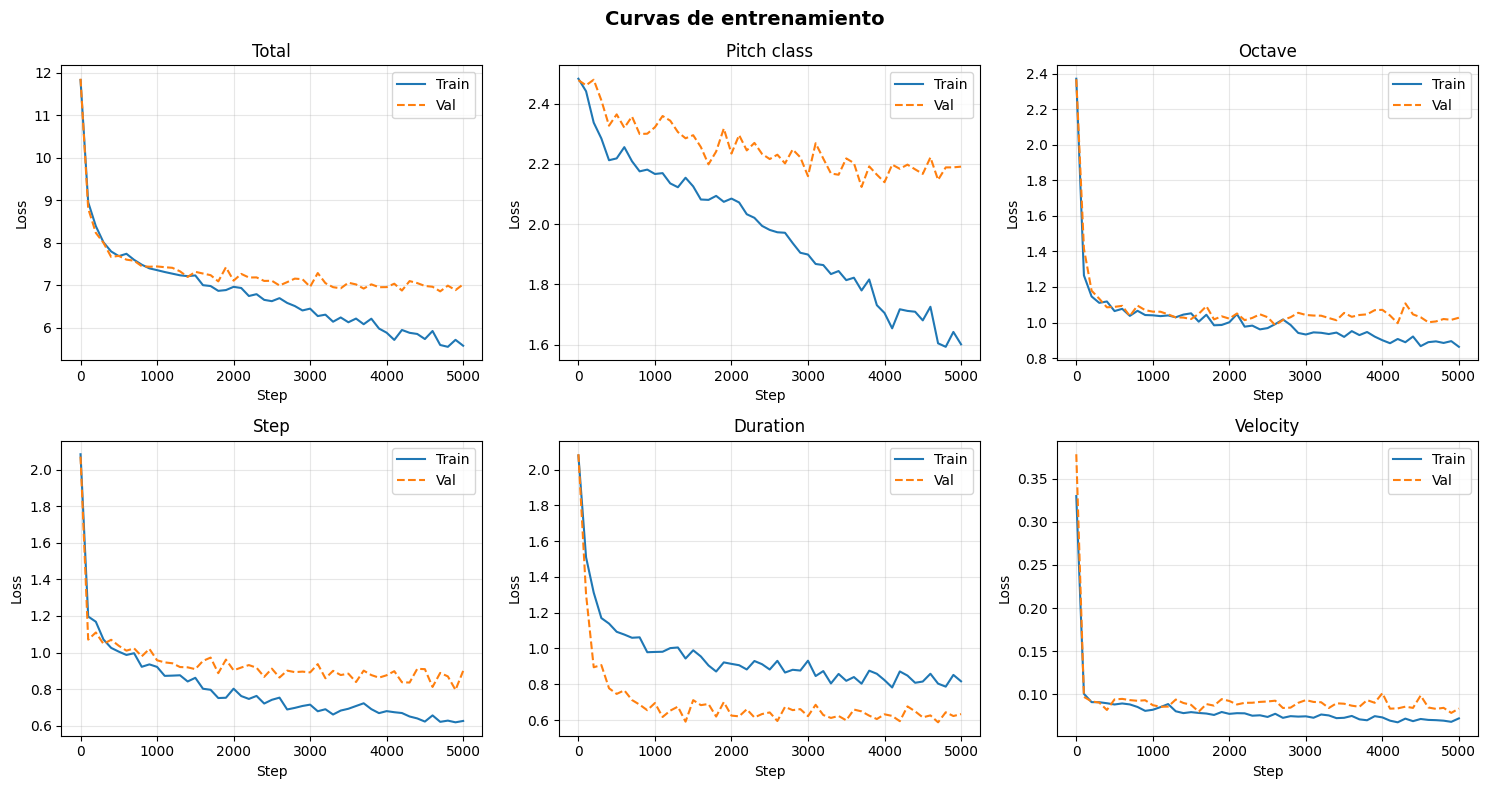

In [88]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

labels = {'total': 'Total', 'pc': 'Pitch class', 'oct': 'Octave',
          'step': 'Step', 'dur': 'Duration', 'vel': 'Velocity'}

steps = [i * EVAL_EVERY for i in range(len(history['train_total']))]

for ax, key in zip(axes, LOSS_KEYS):
    ax.plot(steps, history[f'train_{key}'], label='Train')
    ax.plot(steps, history[f'val_{key}'],   label='Val', linestyle='--')
    ax.set_title(labels[key])
    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Curvas de entrenamiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<a id="sec6"></a>
# 6. Generacion

Se toma una secuencia de test, se usan los primeros `BLOCK_SIZE` pasos como semilla y se generan **100 notas** de forma autorregresiva.

- **Gráfica 1:** Secuencia real completa (primeras `BLOCK_SIZE + 100` notas) en azul.
- **Gráfica 2:** Primeras `BLOCK_SIZE` notas reales en azul + 100 notas generadas por el modelo en verde.

## 6.1 Argmax

Decodificación greedy: en cada paso se elige el token con mayor probabilidad (determinista).

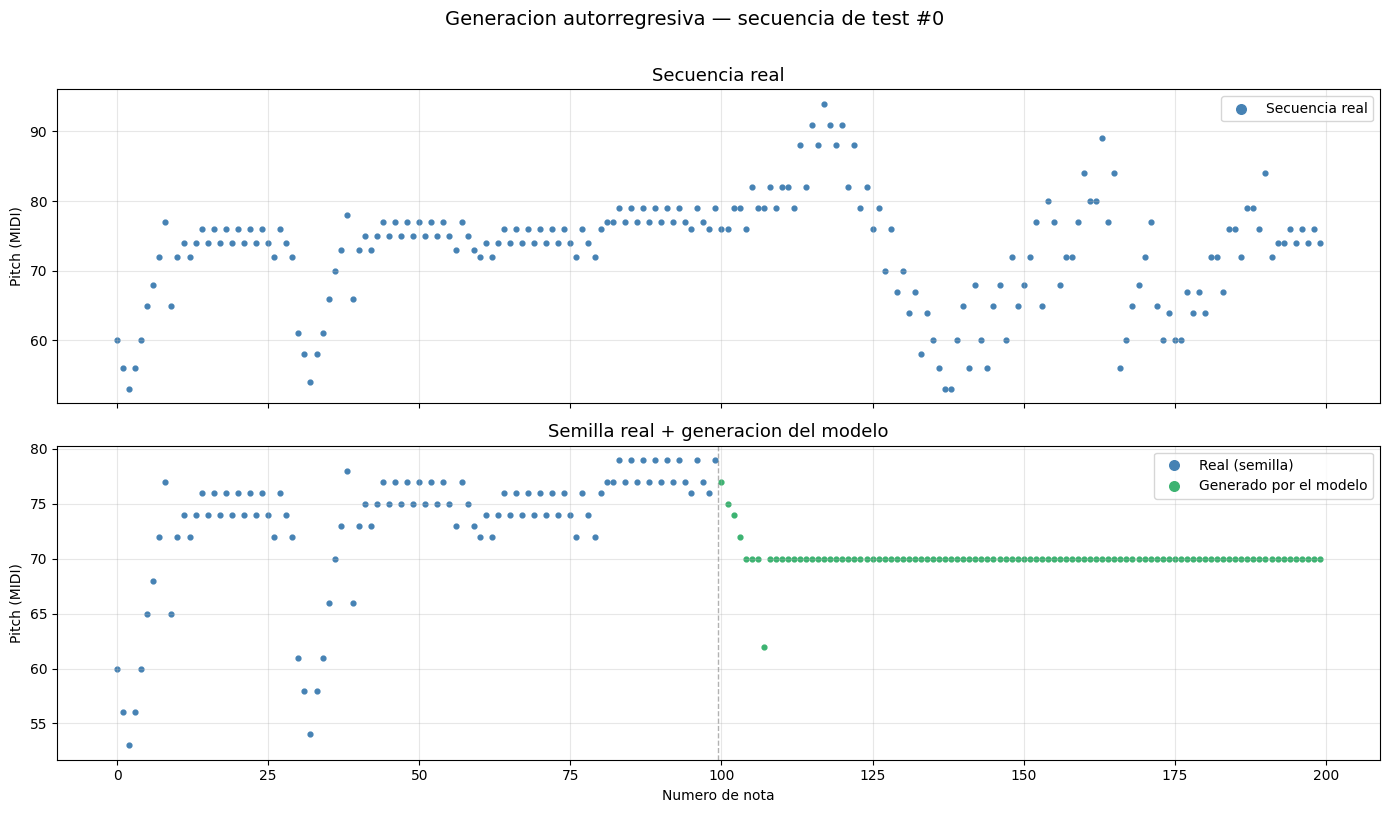

In [89]:
# ── Generación autorregresiva ─────────────────────────────────────────
N_GENERATE = 100

# Seleccionar la primera secuencia de test con suficientes notas
seq_idx = next(i for i, s in enumerate(test_seqs) if len(s) >= BLOCK_SIZE + N_GENERATE)
seq = torch.tensor(test_seqs[seq_idx], dtype=torch.float32)  # (L, 5)

# Semilla: primeros BLOCK_SIZE pasos
seed = seq[:BLOCK_SIZE].clone()  # (BLOCK_SIZE, 5)

# Pitch real de toda la secuencia (para la gráfica 1)
real_pitches = (seq[:, 1].long() * 12 + seq[:, 0].long()).numpy()  # octave*12 + pitch_class

# Generación autorregresiva
model.eval()
window = seed.clone()          # (BLOCK_SIZE, 5)
generated_notes = []

with torch.no_grad():
    for _ in range(N_GENERATE):
        x_in = window.unsqueeze(0).to(device)      # (1, BLOCK_SIZE, 5)
        out  = model(x_in)

        pc_pred  = out['pitch'].argmax(-1).item()   # 0-11
        oct_pred = out['octave'].argmax(-1).item()  # 0-10
        st_pred  = out['step'].argmax(-1).item()    # 0-7
        dur_pred = out['dur'].argmax(-1).item()     # 0-7
        vel_pred = out['vel'].item()

        new_note = torch.tensor(
            [pc_pred, oct_pred, st_pred, dur_pred, vel_pred],
            dtype=torch.float32
        )
        generated_notes.append(new_note)

        # Deslizar la ventana
        window = torch.cat([window[1:], new_note.unsqueeze(0)], dim=0)

gen_tensor   = torch.stack(generated_notes)                        # (N_GENERATE, 5)
gen_pitches  = (gen_tensor[:, 1].long() * 12 + gen_tensor[:, 0].long()).numpy()

# Pitch de la parte real usada como semilla en la gráfica 2
seed_pitches = real_pitches[:BLOCK_SIZE]

# ── Graficas ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Gráfica 1 — Secuencia real completa
x_real = range(BLOCK_SIZE + N_GENERATE)
axes[0].scatter(list(x_real), real_pitches[:BLOCK_SIZE + N_GENERATE],
                color='steelblue', s=12, label='Secuencia real')
axes[0].set_title('Secuencia real', fontsize=13)
axes[0].set_ylabel('Pitch (MIDI)')
axes[0].legend(loc='upper right', markerscale=2)
axes[0].grid(True, alpha=0.3)

# Gráfica 2 — Semilla real (azul) + generada por el modelo (verde)
axes[1].scatter(range(BLOCK_SIZE), seed_pitches,
                color='steelblue', s=12, label='Real (semilla)')
axes[1].scatter(range(BLOCK_SIZE, BLOCK_SIZE + N_GENERATE), gen_pitches,
                color='mediumseagreen', s=12, label='Generado por el modelo')
axes[1].axvline(x=BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('Semilla real + generacion del modelo', fontsize=13)
axes[1].set_ylabel('Pitch (MIDI)')
axes[1].set_xlabel('Numero de nota')
axes[1].legend(loc='upper right', markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Generacion autorregresiva — secuencia de test #{seq_idx}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


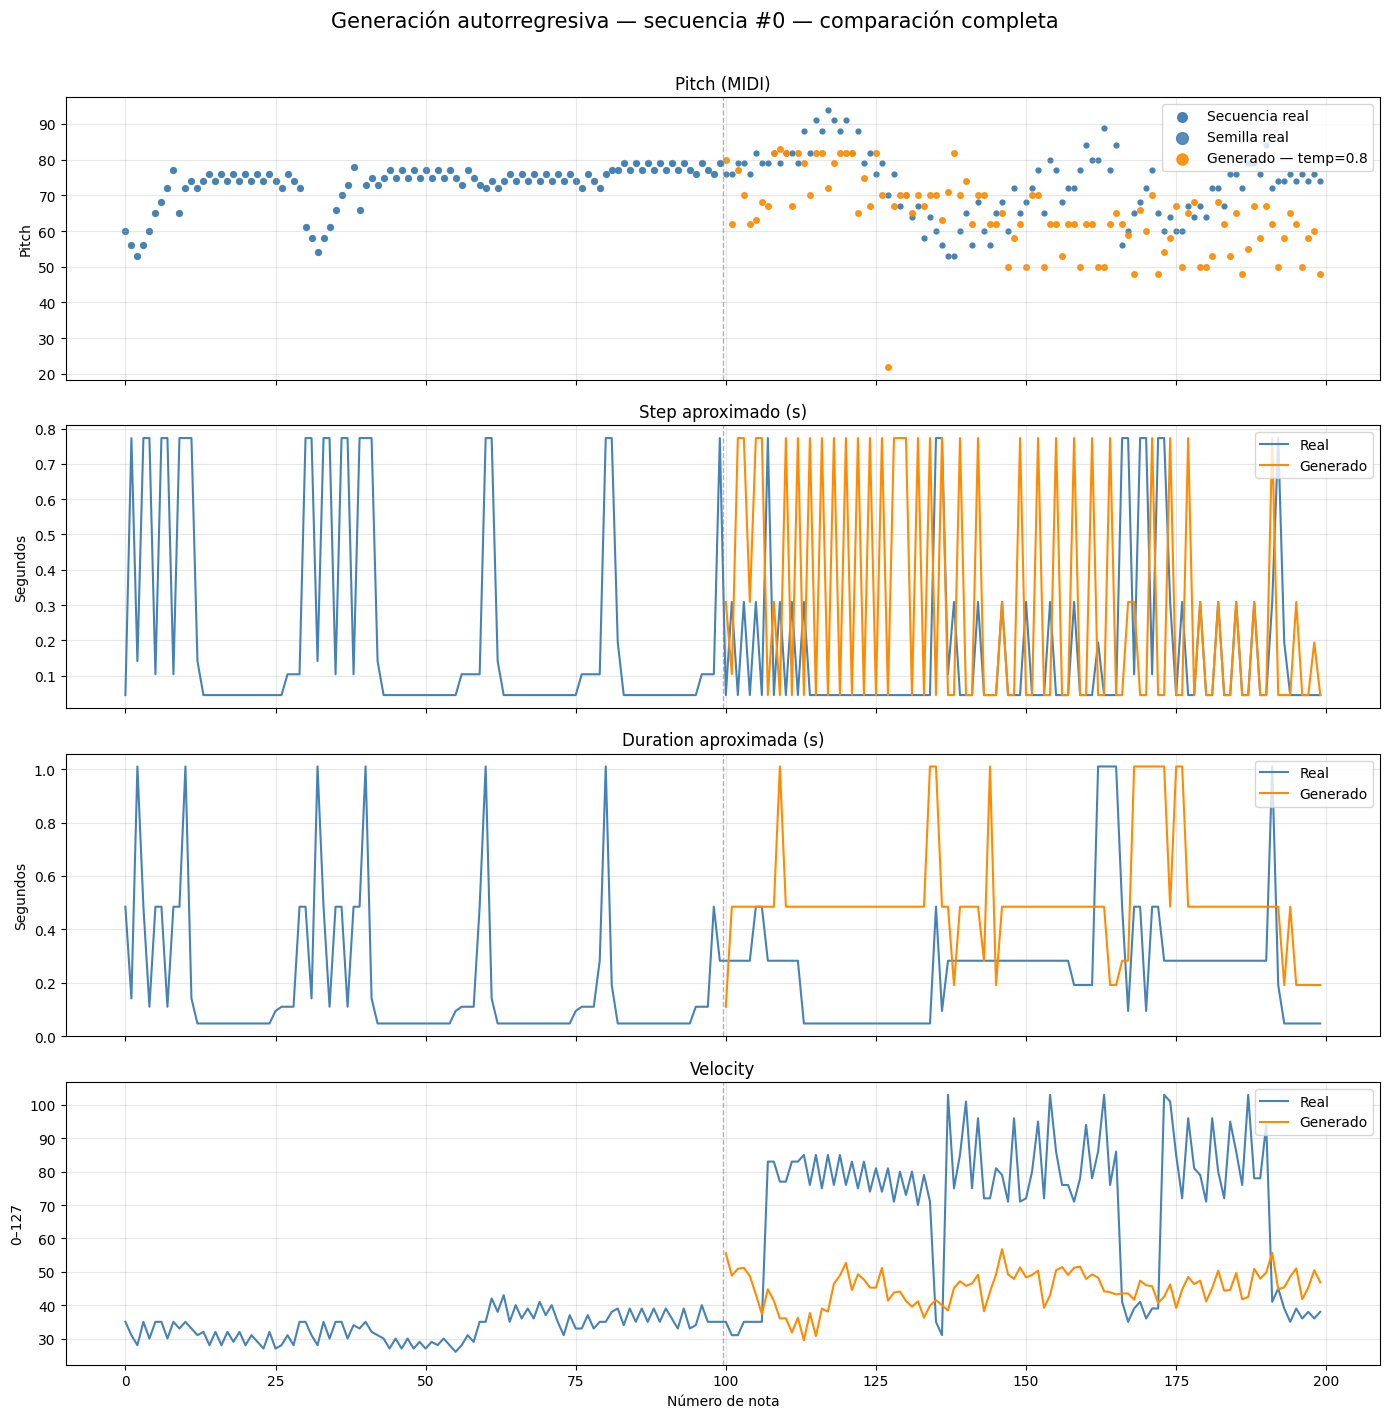

In [99]:
# ── Helpers para decodificar bins a segundos aproximados ──────────────────
def bin_centers_from_edges(edges):
    return (edges[:-1] + edges[1:]) / 2

step_centers = np.expm1(bin_centers_from_edges(params["step_edges"]))   # segundos aprox
dur_centers  = np.expm1(bin_centers_from_edges(params["dur_edges"]))    # segundos aprox

def decode_generated(gen_tensor):
    pc   = gen_tensor[:, 0].long().cpu().numpy()
    octv = gen_tensor[:, 1].long().cpu().numpy()
    step_b = gen_tensor[:, 2].long().cpu().numpy()
    dur_b  = gen_tensor[:, 3].long().cpu().numpy()
    vel_n  = gen_tensor[:, 4].cpu().numpy()

    pitch = octv * 12 + pc
    step  = step_centers[np.clip(step_b, 0, len(step_centers)-1)]
    dur   = dur_centers[np.clip(dur_b, 0, len(dur_centers)-1)]
    vel   = vel_n * 127.0
    return pitch, step, dur, vel

def decode_real_sequence(seq_tensor):
    pc   = seq_tensor[:, 0].long().cpu().numpy()
    octv = seq_tensor[:, 1].long().cpu().numpy()
    step_b = seq_tensor[:, 2].long().cpu().numpy()
    dur_b  = seq_tensor[:, 3].long().cpu().numpy()
    vel_n  = seq_tensor[:, 4].cpu().numpy()

    pitch = octv * 12 + pc
    step  = step_centers[np.clip(step_b, 0, len(step_centers)-1)]
    dur   = dur_centers[np.clip(dur_b, 0, len(dur_centers)-1)]
    vel   = vel_n * 127.0
    return pitch, step, dur, vel

# ── Secuencia real completa de referencia ─────────────────────────────────
# Ajusta esto si tu variable real de secuencia se llama distinto
real_seq_tensor = test_seqs[seq_idx] if isinstance(test_seqs[seq_idx], torch.Tensor) else torch.tensor(test_seqs[seq_idx], dtype=torch.float32)
real_pitch, real_step, real_dur, real_vel = decode_real_sequence(real_seq_tensor)

# semilla real
seed_pitch = real_pitch[:BLOCK_SIZE]
seed_step  = real_step[:BLOCK_SIZE]
seed_dur   = real_dur[:BLOCK_SIZE]
seed_vel   = real_vel[:BLOCK_SIZE]

# generado
gen_pitch, gen_step, gen_dur, gen_vel = decode_generated(gen_tensor_t)

# continuación real para comparar contra lo generado
real_cont_pitch = real_pitch[BLOCK_SIZE:BLOCK_SIZE + N_GENERATE]
real_cont_step  = real_step[BLOCK_SIZE:BLOCK_SIZE + N_GENERATE]
real_cont_dur   = real_dur[BLOCK_SIZE:BLOCK_SIZE + N_GENERATE]
real_cont_vel   = real_vel[BLOCK_SIZE:BLOCK_SIZE + N_GENERATE]

x_seed = np.arange(BLOCK_SIZE)
x_gen  = np.arange(BLOCK_SIZE, BLOCK_SIZE + N_GENERATE)
x_real = np.arange(BLOCK_SIZE + N_GENERATE)

# ── Gráficas completas ────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# 1) Pitch
axes[0].scatter(x_real, real_pitch[:BLOCK_SIZE + N_GENERATE], color='steelblue', s=12, label='Secuencia real')
axes[0].scatter(x_seed, seed_pitch, color='steelblue', s=18, alpha=0.9, label='Semilla real')
axes[0].scatter(x_gen, gen_pitch, color='darkorange', s=16, alpha=0.9, label=f'Generado — temp={TEMPERATURE}')
axes[0].axvline(BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_title('Pitch (MIDI)')
axes[0].set_ylabel('Pitch')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', markerscale=2)

# 2) Step
axes[1].plot(x_real[:BLOCK_SIZE + N_GENERATE], real_step[:BLOCK_SIZE + N_GENERATE], color='steelblue', linewidth=1.5, label='Real')
axes[1].plot(x_gen, gen_step, color='darkorange', linewidth=1.5, label='Generado')
axes[1].axvline(BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title('Step aproximado (s)')
axes[1].set_ylabel('Segundos')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

# 3) Duration
axes[2].plot(x_real[:BLOCK_SIZE + N_GENERATE], real_dur[:BLOCK_SIZE + N_GENERATE], color='steelblue', linewidth=1.5, label='Real')
axes[2].plot(x_gen, gen_dur, color='darkorange', linewidth=1.5, label='Generado')
axes[2].axvline(BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[2].set_title('Duration aproximada (s)')
axes[2].set_ylabel('Segundos')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right')

# 4) Velocity
axes[3].plot(x_real[:BLOCK_SIZE + N_GENERATE], real_vel[:BLOCK_SIZE + N_GENERATE], color='steelblue', linewidth=1.5, label='Real')
axes[3].plot(x_gen, gen_vel, color='darkorange', linewidth=1.5, label='Generado')
axes[3].axvline(BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[3].set_title('Velocity')
axes[3].set_ylabel('0–127')
axes[3].set_xlabel('Número de nota')
axes[3].grid(True, alpha=0.3)
axes[3].legend(loc='upper right')

plt.suptitle(f'Generación autorregresiva — secuencia #{seq_idx} — comparación completa', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

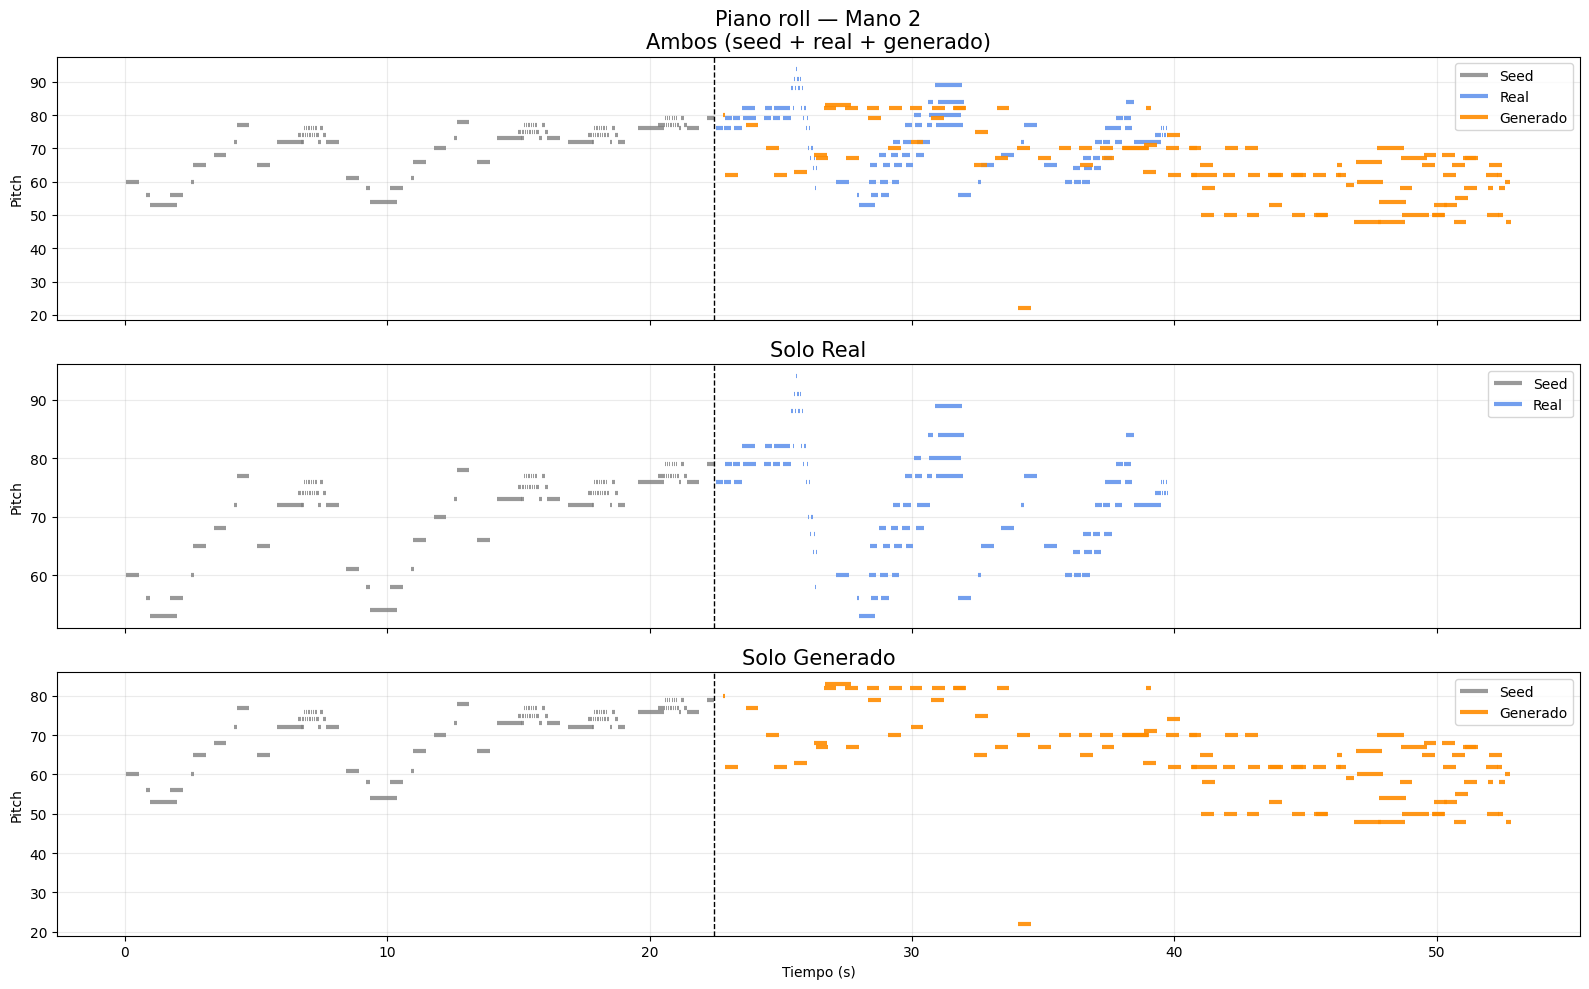

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# ── Helpers ────────────────────────────────────────────────────────────────
def bin_centers_from_edges(edges):
    return (edges[:-1] + edges[1:]) / 2

step_centers = np.expm1(bin_centers_from_edges(params["step_edges"]))
dur_centers  = np.expm1(bin_centers_from_edges(params["dur_edges"]))

def decode_seq(seq_tensor):
    seq = seq_tensor.detach().cpu().numpy() if hasattr(seq_tensor, "detach") else np.asarray(seq_tensor)

    pc   = seq[:, 0].astype(int)
    octv = seq[:, 1].astype(int)
    step_b = seq[:, 2].astype(int)
    dur_b  = seq[:, 3].astype(int)
    vel    = seq[:, 4].astype(float)

    pitch = octv * 12 + pc
    step  = step_centers[np.clip(step_b, 0, len(step_centers)-1)]
    dur   = dur_centers[np.clip(dur_b, 0, len(dur_centers)-1)]

    return pitch, step, dur, vel

def seq_to_roll(pitch, step, dur, start_time=0.0):
    starts = []
    ends   = []
    t = start_time
    for s, d in zip(step, dur):
        t += s
        starts.append(t)
        ends.append(t + d)
    return np.array(starts), np.array(ends), np.array(pitch)

def plot_roll(ax, starts, ends, pitches, color, label=None, lw=3, alpha=0.9):
    for i, (x0, x1, p) in enumerate(zip(starts, ends, pitches)):
        ax.hlines(p, x0, x1, color=color, linewidth=lw, alpha=alpha,
                  label=label if i == 0 and label else None)

# ── Secuencias ─────────────────────────────────────────────────────────────
# secuencia real completa
real_seq = test_seqs[seq_idx]
if not isinstance(real_seq, np.ndarray):
    real_seq = np.array(real_seq, dtype=np.float32)

seed_seq = real_seq[:BLOCK_SIZE]
real_cont_seq = real_seq[BLOCK_SIZE:BLOCK_SIZE + N_GENERATE]

# generado
gen_seq = gen_tensor_t.detach().cpu().numpy()

# decodificar
seed_pitch, seed_step, seed_dur, _ = decode_seq(seed_seq)
real_pitch, real_step, real_dur, _ = decode_seq(real_cont_seq)
gen_pitch,  gen_step,  gen_dur,  _ = decode_seq(gen_seq)

# tiempos
seed_starts, seed_ends, seed_pitch = seq_to_roll(seed_pitch, seed_step, seed_dur, start_time=0.0)
seed_end_time = seed_ends[-1] if len(seed_ends) else 0.0

real_starts, real_ends, real_pitch = seq_to_roll(real_pitch, real_step, real_dur, start_time=seed_end_time)
gen_starts,  gen_ends,  gen_pitch  = seq_to_roll(gen_pitch,  gen_step,  gen_dur,  start_time=seed_end_time)

# ── Gráficas ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# 1) Ambos
plot_roll(axes[0], seed_starts, seed_ends, seed_pitch, color='gray', label='Seed', lw=3, alpha=0.8)
plot_roll(axes[0], real_starts, real_ends, real_pitch, color='cornflowerblue', label='Real', lw=3, alpha=0.9)
plot_roll(axes[0], gen_starts,  gen_ends,  gen_pitch,  color='darkorange', label='Generado', lw=3, alpha=0.9)
axes[0].axvline(seed_end_time, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'Piano roll — Mano 2\nAmbos (seed + real + generado)', fontsize=15)
axes[0].set_ylabel('Pitch')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.25)

# 2) Solo real
plot_roll(axes[1], seed_starts, seed_ends, seed_pitch, color='gray', label='Seed', lw=3, alpha=0.8)
plot_roll(axes[1], real_starts, real_ends, real_pitch, color='cornflowerblue', label='Real', lw=3, alpha=0.9)
axes[1].axvline(seed_end_time, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Solo Real', fontsize=15)
axes[1].set_ylabel('Pitch')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.25)

# 3) Solo generado
plot_roll(axes[2], seed_starts, seed_ends, seed_pitch, color='gray', label='Seed', lw=3, alpha=0.8)
plot_roll(axes[2], gen_starts, gen_ends, gen_pitch, color='darkorange', label='Generado', lw=3, alpha=0.9)
axes[2].axvline(seed_end_time, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Solo Generado', fontsize=15)
axes[2].set_ylabel('Pitch')
axes[2].set_xlabel('Tiempo (s)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 6.2 Temperatura

En lugar de `argmax`, se muestrea de la distribución suavizada por temperatura.
Con `temperature < 1` el modelo es más conservador; con `temperature > 1` más aleatorio.

Se usa **`temperature = 0.8`**.

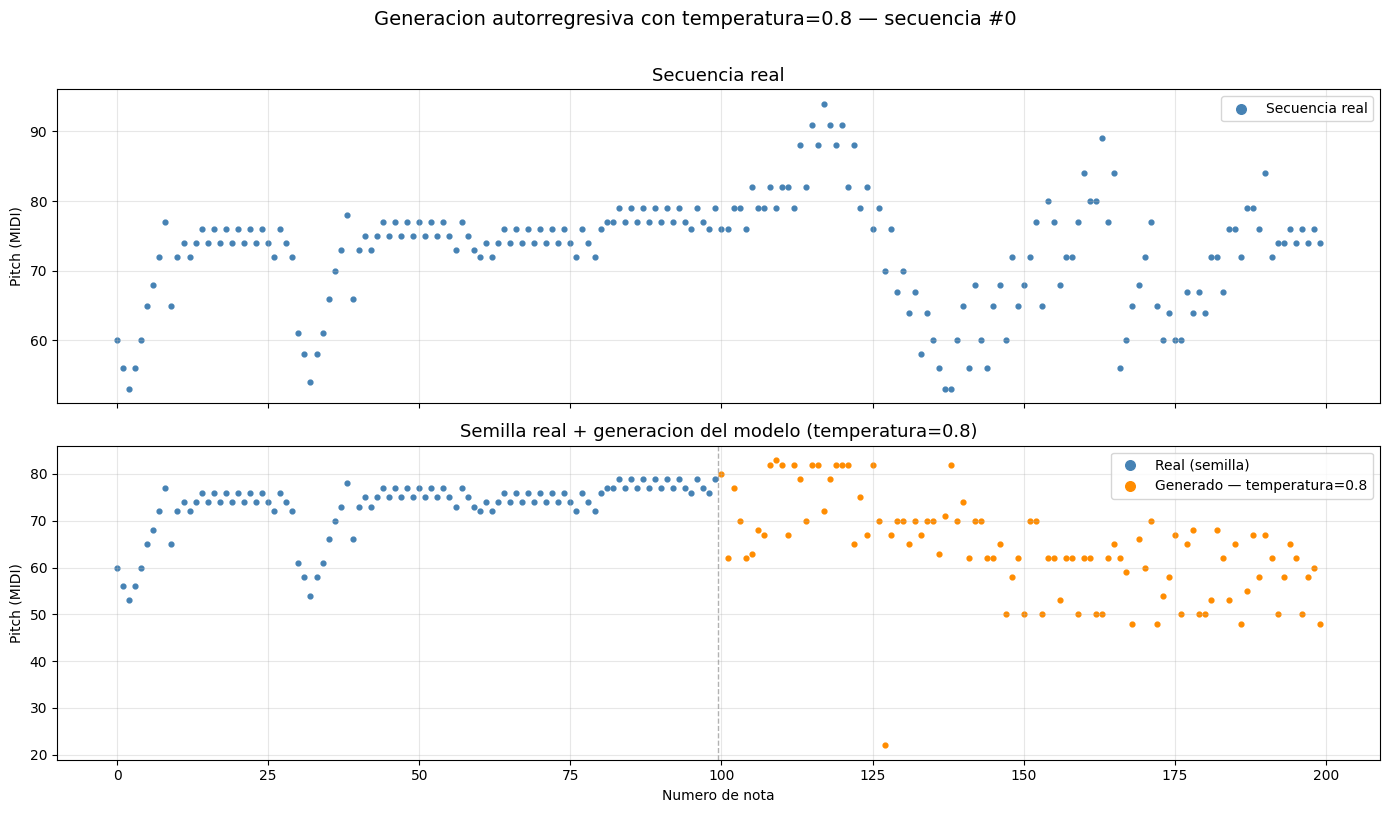

In [90]:
# ── Generación autorregresiva — Temperatura ───────────────────────────
TEMPERATURE = 0.8

def sample_with_temperature(logits, temperature=1.0):
    """Muestrea un índice de los logits escalados por temperatura."""
    scaled = logits / temperature
    probs  = torch.nn.functional.softmax(scaled, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()

model.eval()
window_t = seed.clone()
generated_notes_t = []

with torch.no_grad():
    for _ in range(N_GENERATE):
        x_in = window_t.unsqueeze(0).to(device)          # (1, BLOCK_SIZE, 5)
        out  = model(x_in)

        pc_pred  = sample_with_temperature(out['pitch'],  TEMPERATURE)  # 0-11
        oct_pred = sample_with_temperature(out['octave'], TEMPERATURE)  # 0-10
        st_pred  = sample_with_temperature(out['step'],   TEMPERATURE)  # 0-7
        dur_pred = sample_with_temperature(out['dur'],    TEMPERATURE)  # 0-7
        vel_pred = out['vel'].item()

        new_note = torch.tensor(
            [pc_pred, oct_pred, st_pred, dur_pred, vel_pred],
            dtype=torch.float32
        )
        generated_notes_t.append(new_note)
        window_t = torch.cat([window_t[1:], new_note.unsqueeze(0)], dim=0)

gen_tensor_t  = torch.stack(generated_notes_t)
gen_pitches_t = (gen_tensor_t[:, 1].long() * 12 + gen_tensor_t[:, 0].long()).numpy()

# ── Gráficas ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].scatter(list(range(BLOCK_SIZE + N_GENERATE)), real_pitches[:BLOCK_SIZE + N_GENERATE],
                color='steelblue', s=12, label='Secuencia real')
axes[0].set_title('Secuencia real', fontsize=13)
axes[0].set_ylabel('Pitch (MIDI)')
axes[0].legend(loc='upper right', markerscale=2)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(range(BLOCK_SIZE), seed_pitches,
                color='steelblue', s=12, label='Real (semilla)')
axes[1].scatter(range(BLOCK_SIZE, BLOCK_SIZE + N_GENERATE), gen_pitches_t,
                color='darkorange', s=12, label=f'Generado — temperatura={TEMPERATURE}')
axes[1].axvline(x=BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title(f'Semilla real + generacion del modelo (temperatura={TEMPERATURE})', fontsize=13)
axes[1].set_ylabel('Pitch (MIDI)')
axes[1].set_xlabel('Numero de nota')
axes[1].legend(loc='upper right', markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Generacion autorregresiva con temperatura={TEMPERATURE} — secuencia #{seq_idx}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 6.3 Top-p (Nucleus Sampling)

Se ordenan los tokens de mayor a menor probabilidad y se toma el subconjunto mínimo cuya
probabilidad acumulada supera `top_p`. Solo se muestrea dentro de ese núcleo.

Se usa **`temperature = 0.8`** y **`top_p = 0.8`**.

In [ ]:
# ── Generación autorregresiva — Top-p (Nucleus Sampling) ─────────────
TEMPERATURE_P = 0.8
TOP_P         = 0.8

def sample_top_p(logits, temperature=1.0, top_p=1.0):
    """Top-p (nucleus) sampling sobre los logits de pitch."""
    logits = logits.squeeze()                                      # (vocab,)
    scaled = logits / temperature
    probs  = torch.nn.functional.softmax(scaled, dim=-1)

    # Ordenar de mayor a menor probabilidad
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    # Probabilidad acumulada
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
    # Mantener tokens hasta que la acumulada supere top_p
    cutoff = cumulative_probs <= top_p
    cutoff[0] = True                                               # garantizar al menos un token

    top_p_probs   = sorted_probs[cutoff]
    top_p_probs   = top_p_probs / top_p_probs.sum()               # renormalizar
    sampled_local = torch.multinomial(top_p_probs, num_samples=1) # índice local
    return sorted_indices[sampled_local.item()].item()            # índice original

def sample_temp(logits, temperature=1.0):
    """Muestreo con temperatura (para octave, step, dur)."""
    logits = logits.squeeze()                                      # (vocab,)
    probs  = torch.nn.functional.softmax(logits / temperature, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()

model.eval()
window_p = seed.clone()
generated_notes_p = []

with torch.no_grad():
    for _ in range(N_GENERATE):
        x_in = window_p.unsqueeze(0).to(device)          # (1, BLOCK_SIZE, 5)
        out  = model(x_in)

        pc_pred  = sample_top_p(out['pitch'],  TEMPERATURE_P, TOP_P)  # top-p solo para pitch
        oct_pred = sample_temp(out['octave'],  TEMPERATURE_P)         # temperatura para el resto
        st_pred  = sample_temp(out['step'],    TEMPERATURE_P)
        dur_pred = sample_temp(out['dur'],     TEMPERATURE_P)
        vel_pred = out['vel'].item()

        new_note = torch.tensor(
            [pc_pred, oct_pred, st_pred, dur_pred, vel_pred],
            dtype=torch.float32
        )
        generated_notes_p.append(new_note)
        window_p = torch.cat([window_p[1:], new_note.unsqueeze(0)], dim=0)

gen_tensor_p  = torch.stack(generated_notes_p)
gen_pitches_p = (gen_tensor_p[:, 1].long() * 12 + gen_tensor_p[:, 0].long()).numpy()

# ── Gráficas ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].scatter(list(range(BLOCK_SIZE + N_GENERATE)), real_pitches[:BLOCK_SIZE + N_GENERATE],
                color='steelblue', s=12, label='Secuencia real')
axes[0].set_title('Secuencia real', fontsize=13)
axes[0].set_ylabel('Pitch (MIDI)')
axes[0].legend(loc='upper right', markerscale=2)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(range(BLOCK_SIZE), seed_pitches,
                color='steelblue', s=12, label='Real (semilla)')
axes[1].scatter(range(BLOCK_SIZE, BLOCK_SIZE + N_GENERATE), gen_pitches_p,
                color='mediumpurple', s=12, label=f'Generado — top_p={TOP_P}, temp={TEMPERATURE_P}')
axes[1].axvline(x=BLOCK_SIZE - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[1].set_title(f'Semilla real + generacion del modelo (top_p={TOP_P}, temperatura={TEMPERATURE_P})', fontsize=13)
axes[1].set_ylabel('Pitch (MIDI)')
axes[1].set_xlabel('Numero de nota')
axes[1].legend(loc='upper right', markerscale=2)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Generacion autorregresiva top_p={TOP_P} temp={TEMPERATURE_P} — secuencia #{seq_idx}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
